## BackOrder 예측

In [14]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv('../dataset_v1/Kaggle_Training_Dataset_v2.csv', low_memory=False)
df_train = df_train.iloc[:-1] # 마지막은 종합이라 제거
df_test = pd.read_csv('../dataset_v1/Kaggle_Test_Dataset_v2.csv', low_memory=False)
df_test = df_test.iloc[:-1]

In [15]:
df_train.head()

,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,1026827,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,No,Yes,No,No
1,1043384,2.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.99,0.99,0.0,No,No,No,Yes,No,No
2,1043696,2.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
3,1043852,7.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.10,0.13,0.0,No,No,No,Yes,No,No
4,1044048,8.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No


In [16]:
# 결측치 비율 확인
df_train.isnull().mean() * 100

sku                  0.000000
national_inv         0.000000
lead_time            5.977569
in_transit_qty       0.000000
forecast_3_month     0.000000
forecast_6_month     0.000000
forecast_9_month     0.000000
sales_1_month        0.000000
sales_3_month        0.000000
sales_6_month        0.000000
sales_9_month        0.000000
min_bank             0.000000
potential_issue      0.000000
pieces_past_due      0.000000
perf_6_month_avg     0.000000
perf_12_month_avg    0.000000
local_bo_qty         0.000000
deck_risk            0.000000
oe_constraint        0.000000
ppap_risk            0.000000
stop_auto_buy        0.000000
rev_stop             0.000000
went_on_backorder    0.000000
dtype: float64

> #### 데이터 분할

In [17]:
from sklearn.model_selection import train_test_split

def function_split_data(df):
    df_temp = df.copy()
    X = df_temp.drop(columns=['went_on_backorder'])
    y = df_temp['went_on_backorder']
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
X_train, X_val, y_train, y_val = function_split_data(df_train)
df_val = pd.concat([X_val, y_val], axis=1)

> #### 파생 변수 생성
* 재고 효율성 관련 변수
    - 수요 충족 능력(inventory_coverage): 재고가 예측된 수요를 얼마나 커버하는지. 낮을수록 backorder 위험 증가
    - 재고 회전율(inventory_turnover_ratio): 빠를수록 신선도 높고, 느릴수록 재고 과잉 위험
    - 부족 위험도(stock_shortage_risk): 3개월 수요에서 운송 중 재고를 제외한 것
    - 재고 일수(days_of_stock): 현재 재고로 몇 일을 버틸 수 있는가
* 공급망 관련 변수
    - 공급 준비도(supply_chain_health): 재고 효율성 관련 변수
    - 리드타임 위험도(lead_time_demand_ratio): 정한 리드타임 동안 예상 수요량
    - 발주 긴급성(replenishment_urgency): 현재 공급으로 몇 배 회전할 수 있는가
* 제품 특성 기반 변수
    - 제품중요도(product_criticality): 큰 판매 + 긴 리드 = 높은 중요도
    - 리스크 점수(risk_score): "~여부" 변수 합

In [19]:
def function_make_variable(df):
    df_temp = df.copy()

    # lead_time 결측치는 평균값으로 대체
    df_temp['lead_time'] = df_temp['lead_time'].fillna(df_temp['lead_time'].mean())

    # Yes/No로 되어있는 컬럼을 1/0으로 변환
    binary_cols = ['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop', 'went_on_backorder']
    for col in binary_cols:
        df_temp[col] = df_temp[col].map({'Yes': 1, 'No': 0})

    # 재고 효율성 관련 변수
    df_temp['inventory_coverage'] = (df_temp['national_inv'] / (df_temp['forecast_3_month'] + 1e-6)) # 0으로 나누는거 방지
    df_temp['inventory_turnover_ratio'] = (df_temp['min_bank'] / df_temp['national_inv'].replace(0, 1e-6))
    df_temp['stock_shortage_risk'] = ((df_temp['forecast_3_month'] - df_temp['in_transit_qty']) / df_temp['national_inv'].replace(0, 1e-6))
    df_temp['days_of_stock'] = (df_temp['national_inv'] / (df_temp['sales_1_month'] / 30 + 0.1))
    
    # 공급망 관련 변수
    df_temp['supply_chain_health'] = (df_temp['in_transit_qty'] / (df_temp['national_inv'] + df_temp['in_transit_qty'] + 1e-6))
    df_temp['lead_time_demand_ratio'] = df_temp['lead_time'] * df_temp['forecast_3_month'] / 90
    df_temp['replenishment_urgency'] = df_temp['forecast_3_month'] / (df_temp['national_inv'] + df_temp['in_transit_qty'] + 1e-6)

    # 제품 특성 기반 변수
    df_temp['avg_sales'] = df_temp['sales_1_month']*0.4 + df_temp['sales_3_month']*0.3 + df_temp['sales_6_month']*0.2 + df_temp['sales_9_month']*0.1 # 최근 수요에 가중합
    df_temp['sales_importance'] = df_temp['avg_sales'] / df_temp['avg_sales'].max()

    forecast_cols = ['forecast_3_month', 'forecast_6_month', 'forecast_9_month']
    df_temp['forecast_volatility'] = df_temp[forecast_cols].std(axis=1) / (df_temp[forecast_cols].mean(axis=1) + 1e-6)

    df_temp['product_criticality'] = df_temp['sales_importance'] * df_temp['lead_time'] * df_temp['forecast_volatility']
    
    risk_cols = ['potential_issue', 'deck_risk', 'oe_constraint', 'ppap_risk', 'stop_auto_buy', 'rev_stop']
    df_temp['overall_risk_score'] = df_temp[risk_cols].sum(axis=1)

    taking_cols = ['min_bank', 'inventory_coverage', 'inventory_turnover_ratio', 'stock_shortage_risk', 'days_of_stock',
                   'supply_chain_health', 'lead_time_demand_ratio', 'replenishment_urgency', 'sales_importance', 'forecast_volatility', 'product_criticality', 'overall_risk_score', 'went_on_backorder']
    df_temp = df_temp[taking_cols]

    return df_temp

In [20]:
df_train_processed = function_make_variable(df_train)
df_val_processed = function_make_variable(df_val)
df_test_processed = function_make_variable(df_test)

print(f"train shape: {df_train_processed.shape[0]}\nval shape: {df_val_processed.shape[0]}\ntest shape: {df_test_processed.shape[0]}")

train shape: 1687860
val shape: 337572
test shape: 242075


In [21]:
# 정규화 및 X, y 분리
from sklearn.preprocessing import StandardScaler

def function_X_y(df):
    df_temp = df.copy()
    X = df_temp.drop(columns=['went_on_backorder'])
    y = df_temp['went_on_backorder']

    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    return X, y

X_train_final, y_train_final = function_X_y(df_train_processed)
X_val_final, y_val_final = function_X_y(df_val_processed)
X_test_final, y_test_final = function_X_y(df_test_processed)

In [22]:
from torch.utils.data import DataLoader, TensorDataset
import torch

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_final, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_final, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_final.values, dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val_final.values, dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test_final.values, dtype=torch.float32)

In [23]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

> ### 모델 설계

In [24]:
import torch.nn as nn
import torch.optim as optim

class BasicMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 불균형 처리: 가중치 계산
pos_weight = (y_train_tensor == 0).sum() / (y_train_tensor == 1).sum()
print(f"Class weight (positive): {pos_weight:.1f}x")

model = BasicMLP(input_dim=12).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Using device: cuda
Class weight (positive): 148.5x


In [26]:
from tqdm.auto import tqdm

epochs = 50
best_val_loss = float('inf')
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
}

for epoch in tqdm(range(epochs), desc="Training"):
    model.train()
    train_loss = 0
    
    for batch_x, batch_y in tqdm(train_loader, desc="Training Batches", leave=False):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        batch_y = batch_y.float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # 검증
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():  # 그래디언트 계산 안 함
        for batch_x, batch_y in tqdm(val_loader, desc="Validation Batches", leave=False):
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            batch_y = batch_y.float().unsqueeze(1)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            
            # 정확도 계산
            probs = torch.sigmoid(outputs)
            predictions = (probs >= 0.5).float()
            val_correct += (predictions == batch_y).sum().item()
            val_total += batch_y.size(0)
    
    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_mlp_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print("Early stopping!")
            break

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if (epoch + 1) % 3 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

Training:   0%|          | 0/50 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/6594 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/1319 [00:00<?, ?it/s]

Training Batches:   0%|          | 0/6594 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/1319 [00:00<?, ?it/s]

...

Validation Batches:   0%|          | 0/1319 [00:00<?, ?it/s]

Epoch 24/50, Train Loss: 0.7917, Val Loss: 0.7986, Val Accuracy: 0.7732


Training Batches:   0%|          | 0/6594 [00:00<?, ?it/s]

Validation Batches:   0%|          | 0/1319 [00:00<?, ?it/s]

Early stopping!


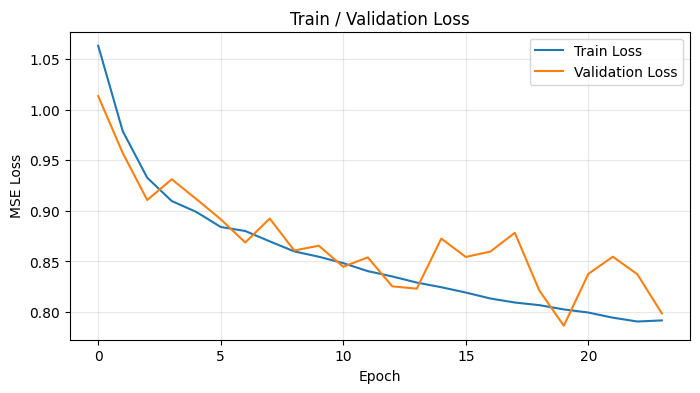

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Train / Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [30]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. 모델 생성 후 pth 불러오기
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
model = BasicMLP(input_dim=12).to(device)
model.load_state_dict(torch.load("best_mlp_model.pth", map_location=device))
model.eval()

# 2. test_loader 평가
all_preds = []
all_labels = []

test_loss = 0.0

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float().unsqueeze(1)

        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.cpu().numpy().astype(int).flatten())
        all_labels.extend(batch_y.cpu().numpy().astype(int).flatten())

test_loss /= len(test_loader)

# 3. 성능 지표
acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Class 0", "Class 1"]))

Using device: cuda
Test Loss: 1.1191
Test Accuracy: 0.7643

Confusion Matrix:
[[182632  56755]
 [   308   2380]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       1.00      0.76      0.86    239387
     Class 1       0.04      0.89      0.08      2688

    accuracy                           0.76    242075
   macro avg       0.52      0.82      0.47    242075
weighted avg       0.99      0.76      0.86    242075

